<a href="https://colab.research.google.com/github/MadisonJBollinger/lis5693/blob/main/lab-6/Lab_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [187]:
!pip install textnets

In [188]:
import textnets as tn
import pandas as pd
import matplotlib.pyplot as plt

In [189]:
tn.params["seed"] = 42

In [190]:
url = "https://raw.githubusercontent.com/MadisonJBollinger/lis5693/main/lab-5/church-attendance.csv"
df = pd.read_csv(url)
df.head()

,Lens ID,Title,Date Published,Publication Year,Publication Type,Source Title,ISSNs,Publisher,Source Country,Author/s,...,PMID,DOI,Microsoft Academic ID,PMCID,Citing Patents Count,References,Citing Works Count,Is Open Access,Open Access License,Open Access Colour
0,000-084-742-436-091,Educational Cooperation Between Church and State,NaN,1949.0,journal article,Law and Contemporary Problems,00239186,JSTOR,United States,Alexander Meiklejohn,...,NaN,10.2307/1189948,1563606935,NaN,0,NaN,2,True,NaN,green
1,000-357-020-721-107,Infidels and the Damn Churches,2017-03-17,2017.0,book,NaN,NaN,University of British Columbia Press,NaN,Lynne Marks,...,NaN,10.59962/9780774833462,NaN,NaN,0,NaN,95,False,NaN,NaN
2,000-653-276-408-719,Vaccine Exemptions and the Church-State Problem.,2017-09-01,2017.0,journal article,The Journal of clinical ethics,10467890; 19455879,University of Chicago Press,United States,Dena S Davis,...,28930714.0,10.1086/jce2017283250,3024947021,NaN,0,NaN,2,False,NaN,NaN
3,000-770-958-542-889,More evidence on U.S. Catholic church attendance,NaN,1994.0,journal article,Journal for the Scientific Study of Religion,00218294,JSTOR,United States,Mark Chaves; James C. Cavendish,...,NaN,10.2307/1386496,2333783025,NaN,0,077-775-176-038-801; 123-163-389-214-564,80,False,NaN,NaN
4,000-802-793-861-390,Church and Organ Music. Church Music: The Use ...,1919-06-01,1919.0,journal article,The Musical Times,00274666,JSTOR,United Kingdom,Ulric Daubeny,...,NaN,10.2307/3701831,2802320635,NaN,0,NaN,0,True,cc0,green


In [191]:
df = df[["Title", "Abstract"]].copy()
df = df.dropna(subset=["Title", "Abstract"])

df=df.head(15).copy()
print(df.shape)
df.head()

(15, 2)


,Title,Abstract
0,Educational Cooperation Between Church and State,"""Congress shall make no law respecting an esta..."
1,Infidels and the Damn Churches,British Columbia is at the forefront of a secu...
2,Vaccine Exemptions and the Church-State Problem.,All of the 50 states of the United States have...
3,More evidence on U.S. Catholic church attendance,"Hadaway, Marler et Chaves ont recemment affirm..."
4,Church and Organ Music. Church Music: The Use ...,JSTOR is a not-for-profit service that helps s...


In [192]:
df.to_csv("lab6_church_attendance.csv", index=False)

In [193]:
df["text"] = df["Title"].astype(str) + ". " + df["Abstract"].astype(str)
df["doc_id"] = [f"Source_{i+1}" for i in range(len(df))]


docs = pd.Series(df["text"].values, index=df["doc_id"])

docs.head()

,0
doc_id,
Source_1,Educational Cooperation Between Church and Sta...
Source_2,Infidels and the Damn Churches. British Columb...
Source_3,Vaccine Exemptions and the Church-State Proble...
Source_4,More evidence on U.S. Catholic church attendan...
Source_5,Church and Organ Music. Church Music: The Use ...


In [194]:
corpus = tn.Corpus(docs, lang="en")
corpus

<Corpus with 15 documents using language model 'en_core_web_sm'>

In [195]:
corpus

<Corpus with 15 documents using language model 'en_core_web_sm'>

In [196]:
t = tn.Textnet(corpus.tokenized(), min_docs=2)

0docs [00:00, ?docs/s]

Task 2: Perform text pre-processing.
How many terms and edges are in your dataset?

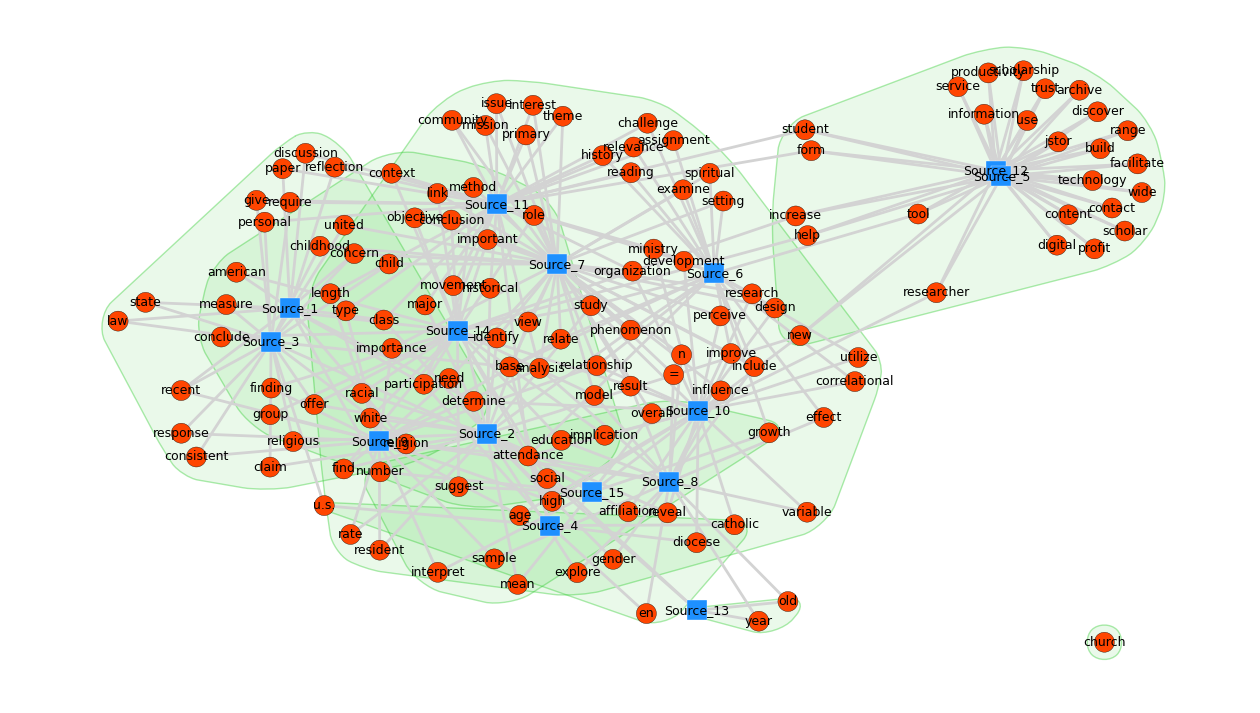

In [197]:
t.plot(label_nodes=True,
       show_clusters=True)

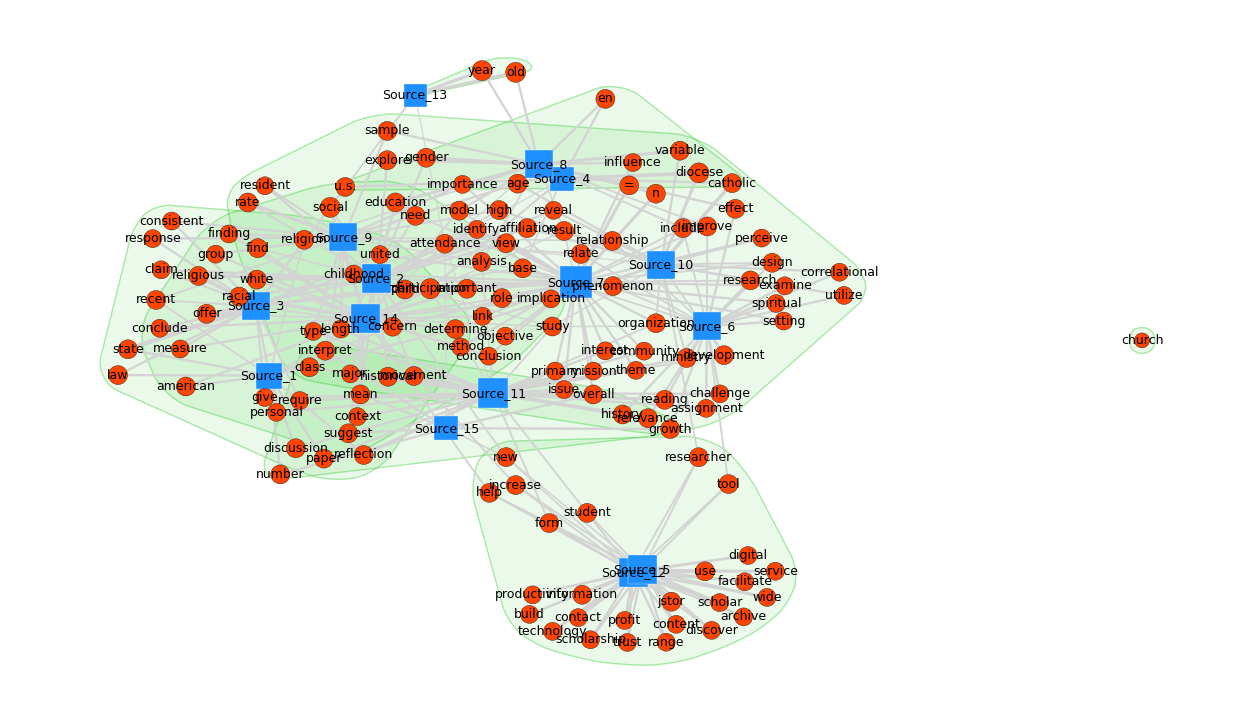

In [198]:
t.plot(label_nodes=True,
       show_clusters=True,
       scale_nodes_by="birank",
       scale_edges_by="weight")

In [199]:
print("Number of nodes:", len(t.nodes))
print("Number of edges:", len(t.edges))


Number of nodes: 150
Number of edges: 318


This coding shows that there are 150 unique terms with 318 edges between the 150 terms in my 15 datapoints from the .csv with a limit of minimum documents referencing them to two.

In [200]:
terms = t.project(node_type=tn.TERM, connected=True)

In [201]:
terms.top_cluster_nodes()

,nodes,size
cluster,,
0,"[racial, religious, social, find, offer, white...",43
1,"[child, important, role, view, =, n, research,...",37
2,"[history, historical, movement, reading, relev...",28
3,"[use, information, jstor, profit, trust, schol...",26


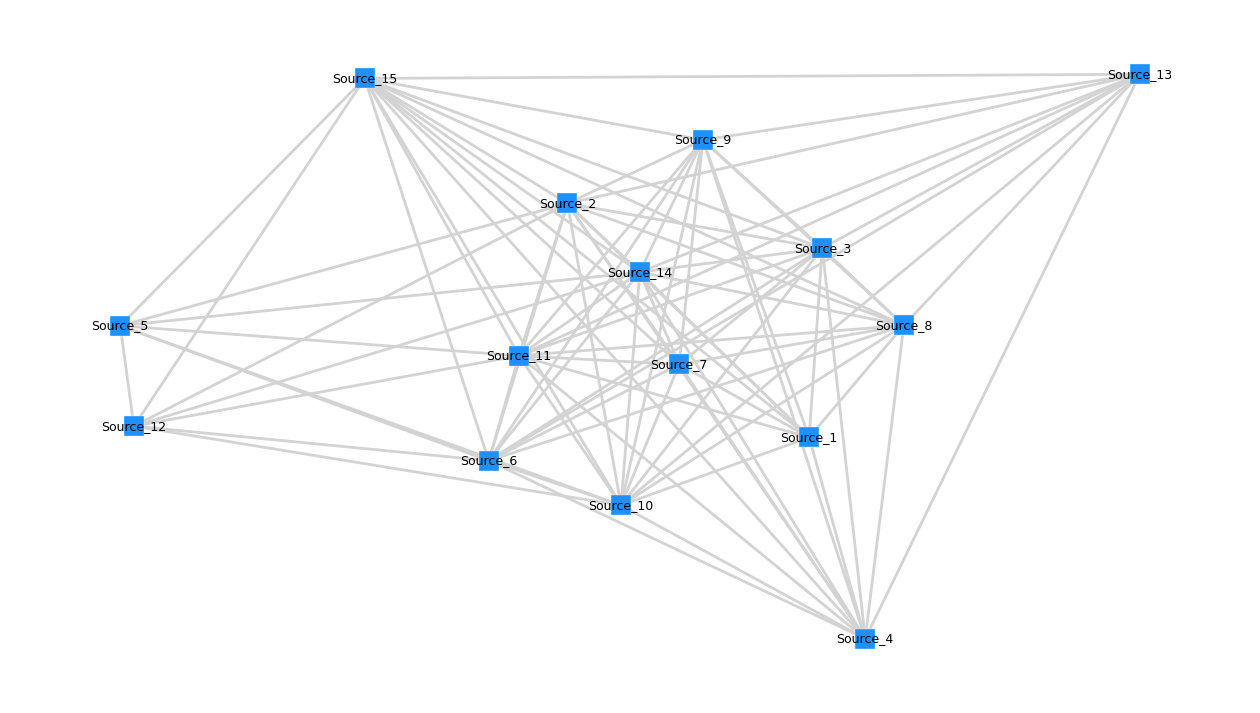

In [202]:
papers = t.project(node_type=tn.DOC)
papers.plot(label_nodes=True)

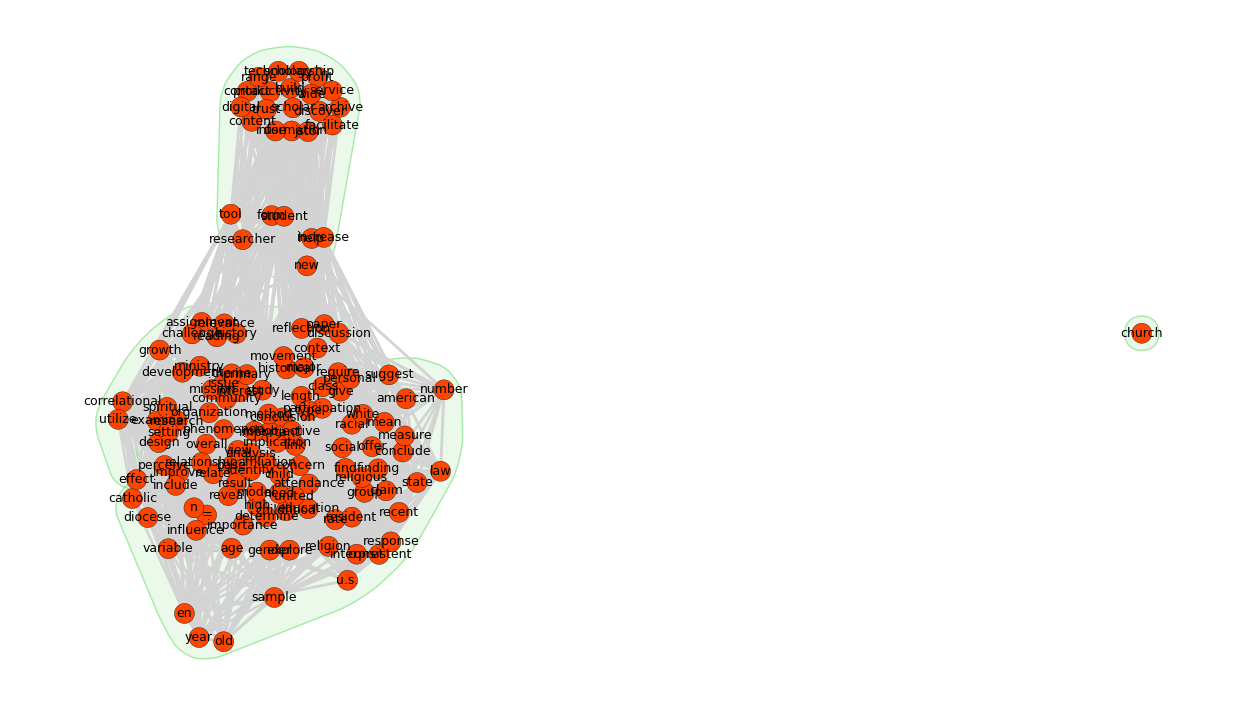

In [203]:
words = t.project(node_type=tn.TERM)
words.plot(label_nodes=True,
           show_clusters=True)

The term–term network represents relationships between words that co-occur in the same documents. In this network, nodes are terms, and edges connect terms that appear together.

In [204]:
t.top_degree()

,0
Source_7,40
Source_11,33
Source_14,27
Source_12,26
Source_2,26
Source_5,26
Source_6,25
Source_10,22
Source_3,21
Source_9,21


In [205]:
t.top_birank()

,0
Source_7,0.058463
Source_11,0.053800
Source_14,0.050281
Source_2,0.048561
Source_5,0.048190
Source_12,0.048062
Source_6,0.046036
Source_3,0.045925
Source_10,0.045634
Source_8,0.044779


In [206]:
papers.top_betweenness()

,0
Source_14,12.0
Source_11,11.0
Source_7,10.0
Source_10,8.0
Source_8,7.0
Source_2,4.0
Source_1,0.0
Source_15,0.0
Source_13,0.0
Source_12,0.0


In [207]:
words.top_betweenness()

,0
important,534.000000
child,436.000000
new,431.000000
help,338.666667
increase,338.666667
religious,315.500000
researcher,290.750000
student,267.083333
form,267.083333
tool,261.750000


In [208]:
words.top_cluster_nodes()

,nodes,size
cluster,,
0,"[racial, religious, social, find, offer, white...",43
1,"[child, important, role, view, =, n, identify,...",40
2,"[use, information, jstor, archive, trust, serv...",26
3,"[history, relevance, reading, historical, move...",25
4,church,1


In [ ]:
Based on the clusters: Racial and religious, child and role, and history and relevance are three strongly connected word pairs.

This implies that racial background is a factor in what religion you might chose, while the role children play in religion can vary enough to study. Also, as we know history plays a role in the relevance of certain aspects in religions.


In [ ]:
Also compared to Lab-5 there are similar topics in the top but with the pairing down it has changed the main topics. The 5 clusters I received wer of race and religioin, role and view of children in religion, the use of information, history of the church , and church.

0edges [00:00, ?edges/s]

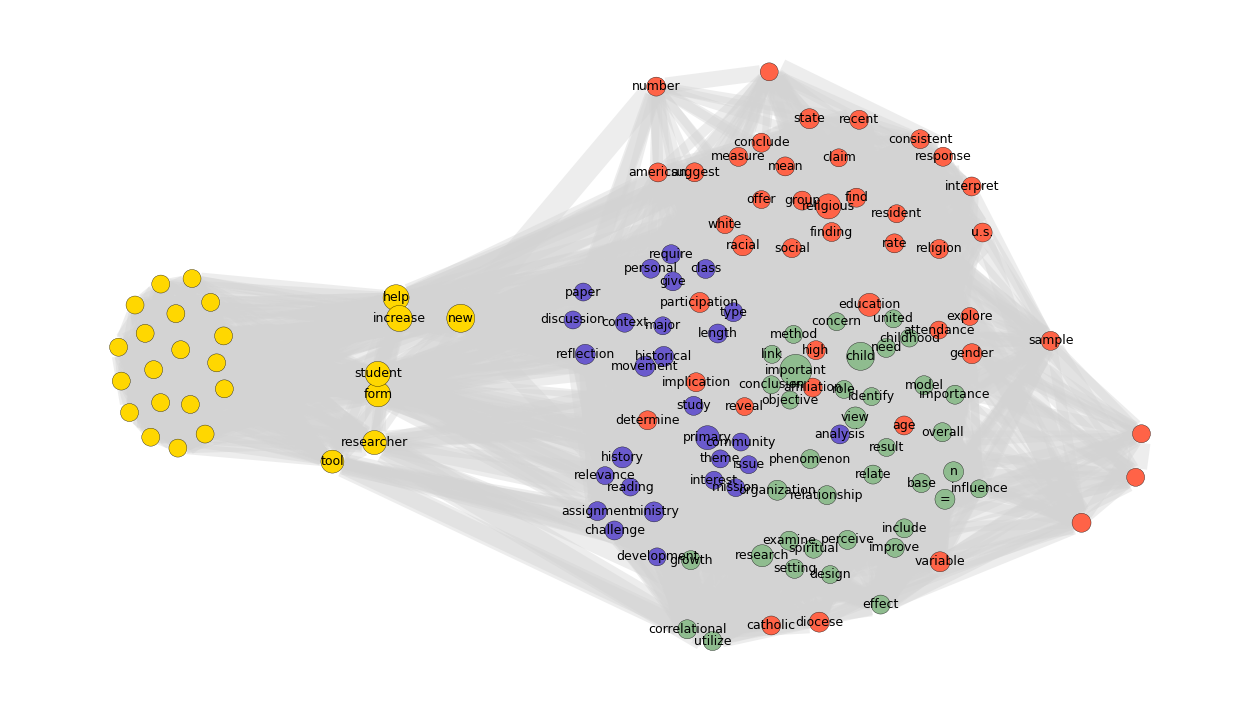

In [209]:
words.plot(label_nodes=True,
           scale_nodes_by="betweenness",
           color_clusters=True,
           alpha=0.5,
           edge_width=[10*w for w in words.edges["weight"]],
           edge_opacity=0.4,
           node_label_filter=lambda n: n.betweenness() > words.betweenness.median())

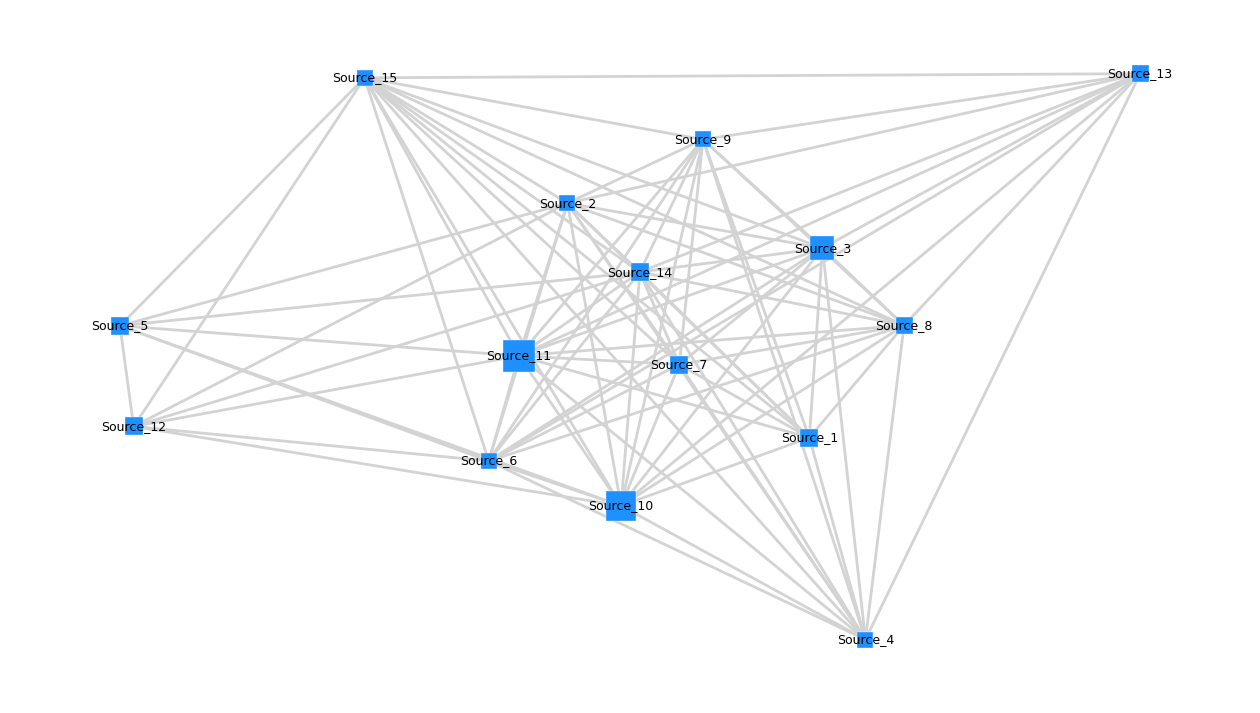

In [210]:
papers.plot(label_nodes=True,
            scale_nodes_by="spanning")

In [233]:
words.save_graph("term_network.gml")

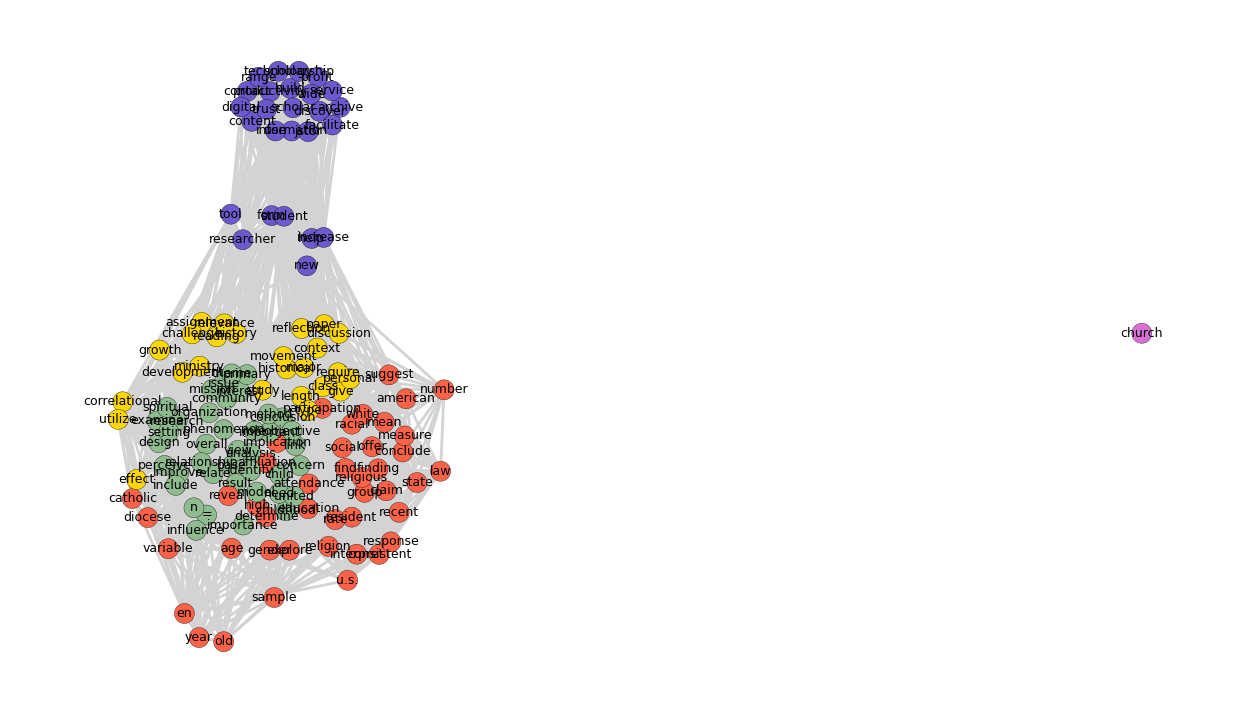

In [232]:
words.plot(label_nodes=True, color_clusters=True)
tn.savefig("term_network.svg")

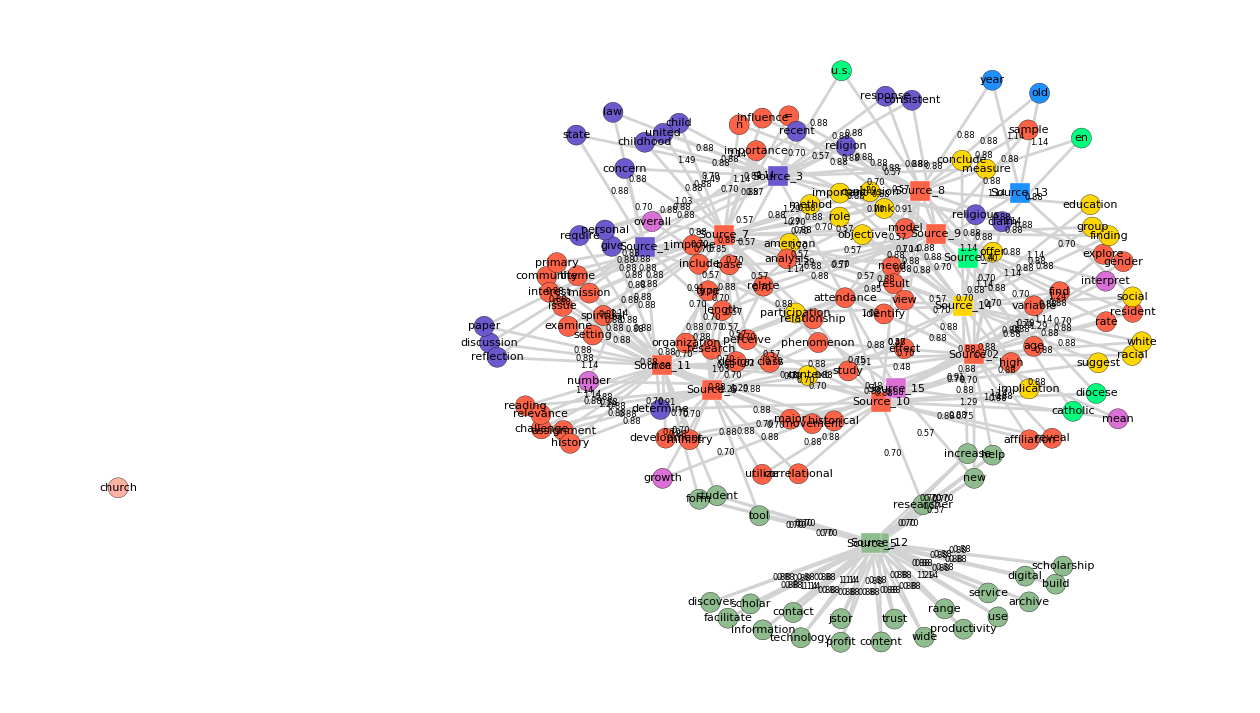

In [213]:
import matplotlib.pyplot as plt
t.plot(label_nodes=True,
       node_label_size=8,
       label_edges=True,
       edge_label_size=6,
       edge_label_filter=lambda e: e["weight"] > 0.3,
       color_clusters=True,
       kamada_kawai_layout=True)
plt.savefig("church_attendance.eps")

In [214]:
!ls *.eps

church_attendance.eps


Reflection:

The assignment work itself was great and easy to follow. The one thing I didn't like that I made a change to towards the end was I started with 20 sources and it was so cluttered it was hard to read any of the graphs, so I dropped to 15, which helped clear up and create a visually bigger graph that allowed me to interpret the data easier. I also made the decision to increase min_doc to 2 to allow for less words and give cleaner graphs that with just 1 doc.

Utilizing this will allow me to do not only professional work, but in future classes running a program like this lab will give me great resources for papers or interest topics that can take less time in procurring than if I did only key word searches in a database.